In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load the dataset
df = pd.read_csv("retail_sales_dataset.csv")

# Display the first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
# Shape of the dataset
print("Shape of the dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of the dataset: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


## Observation

- The dataset contains 1000 rows and 9 columns.
- No significant missing values were found.
- The dataset includes customer demographics, product information, and sales details, making it suitable for exploratory analysis.

In [4]:
# Descriptive Statistics
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
# Mean
print("Mean")
print(df.mean(numeric_only=True))

# Median
print("\nMedian")
print(df.median(numeric_only=True))

# Mode
print("\nMode")
print(df.mode())

# Standard Deviation
print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode
     Transaction ID        Date Customer ID  Gender   Age Product Category  \
0                 1  2023-05-16     CUST001  Female  43.0         Clothing   
1                 2         NaN     CUST002     NaN  64.0              NaN   
2                 3         NaN     CUST003     NaN   NaN              NaN   
3                 4         NaN     CUST004     NaN   NaN              NaN   
4                 5         NaN     CUST005     NaN   NaN              NaN   
..              ...         ...         ...     ...   ...              ...   
995             996         NaN     CUST995     NaN   NaN              NaN   
996             997         NaN     CUST996     NaN   NaN              NaN   

## Observation

- The average sales amount is 456.
- The customer age is centered around 41 years.
- The standard deviation indicates variability in purchase amounts across customers.

In [6]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check the data type
print(df['Date'].dtype)

datetime64[us]


# Monthly Sales Trend


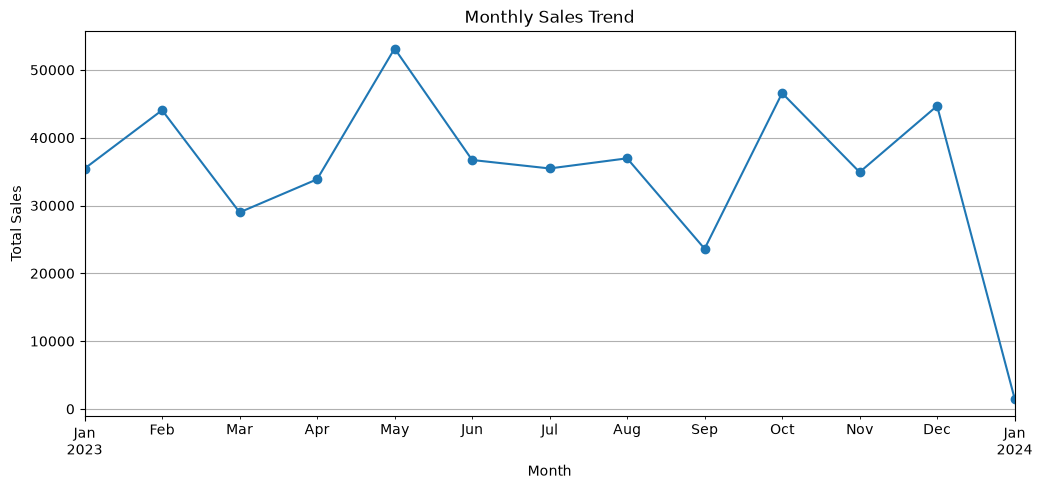

In [15]:
# Create Month column
df['Month'] = df['Date'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Plot
plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("images/monthly_sales.png")

plt.show()


## Observation

- The monthly sales trend shows how sales fluctuate over different months.
- Some months record higher sales, indicating increased customer demand.
- Businesses can use this information to plan inventory and promotional campaigns.

# Quarterly Sales Trend


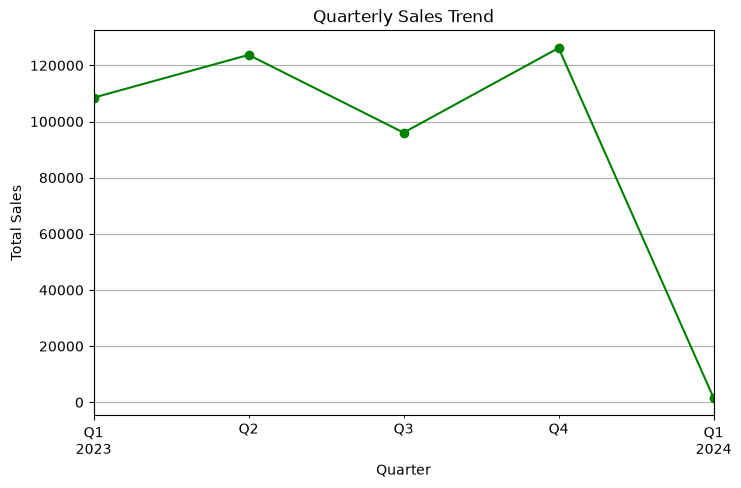

In [16]:
# Create Quarter column
df['Quarter'] = df['Date'].dt.to_period('Q')

# Calculate quarterly sales
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

# Plot
plt.figure(figsize=(8,5))
quarterly_sales.plot(marker='o', color='green')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("images/quarterly_sales.png")

plt.show()

## Observation

- Quarterly sales provide an overall view of business performance.
- Comparing quarters helps identify stronger and weaker sales periods.


# Gender Distribution

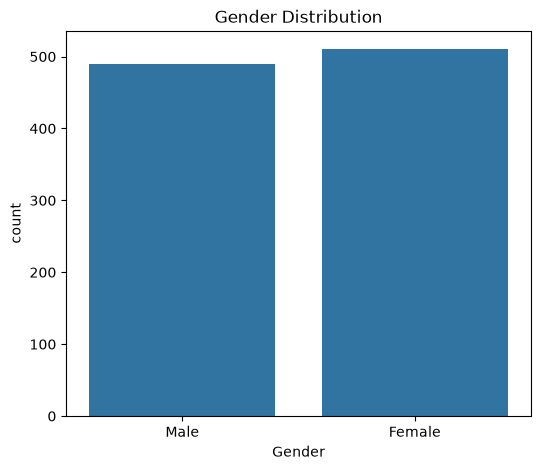

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution")
plt.savefig("images/gender_distribution.png")

plt.show()

## Observation

- The chart shows the distribution of male and female customers.
- This helps understand the customer base and supports targeted marketing strategies.

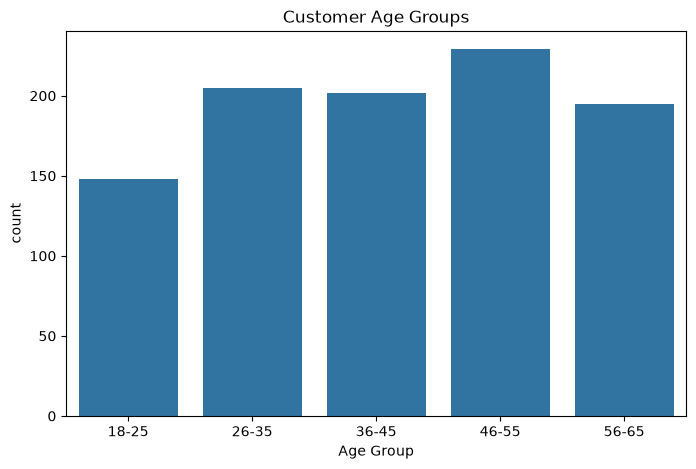

In [18]:
# Create Age Groups
bins = [18,25,35,45,55,65]
labels = ['18-25','26-35','36-45','46-55','56-65']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Age Group')

plt.title("Customer Age Groups")
plt.savefig("images/age_distribution.png")

plt.show()

## Observation

- The chart displays the distribution of customers across different age groups.
- It helps identify the primary customer segment for the business.

# Top 10 Best-Selling Products

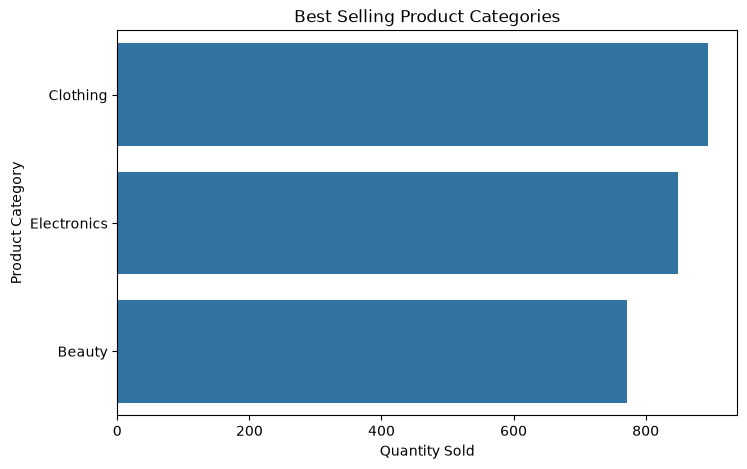

In [11]:
# Top 10 products based on quantity sold

top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Best Selling Product Categories")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.show()

## Observation

- The chart shows which product categories have the highest sales volume.
- The most purchased category can be prioritized for inventory and marketing campaigns.

# Revenue by Product Category

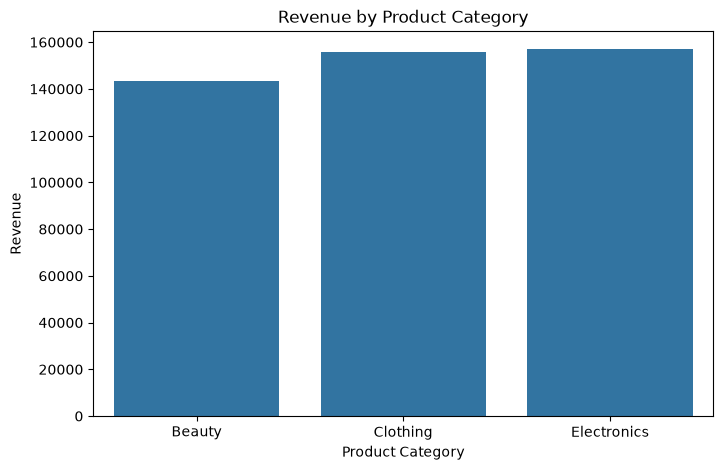

In [19]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.savefig("images/revenue_by_category.png")

plt.show()

## Observation

- The revenue generated by each product category is displayed.
- Categories with higher revenue contribute more significantly to the business.

# Correlation Heatmap

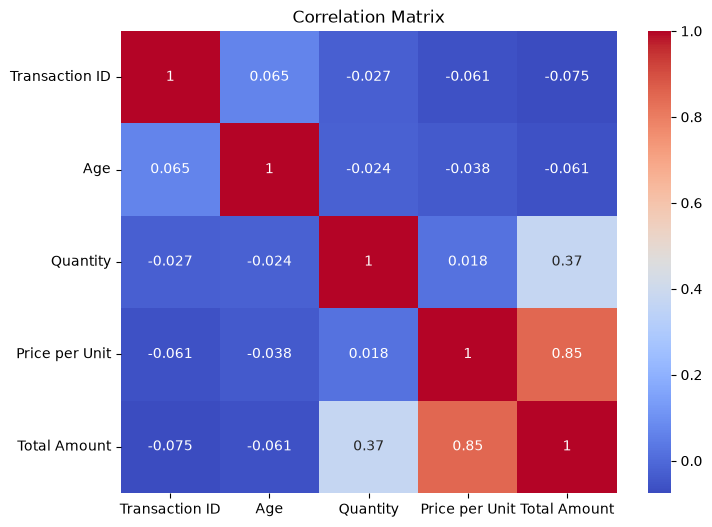

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.savefig("images/correlation_heatmap.png")

plt.show()

## Observation

- The heatmap illustrates relationships between numerical variables.
- Strong positive or negative correlations help identify factors that influence sales.

# Sales Distribution by Product Category

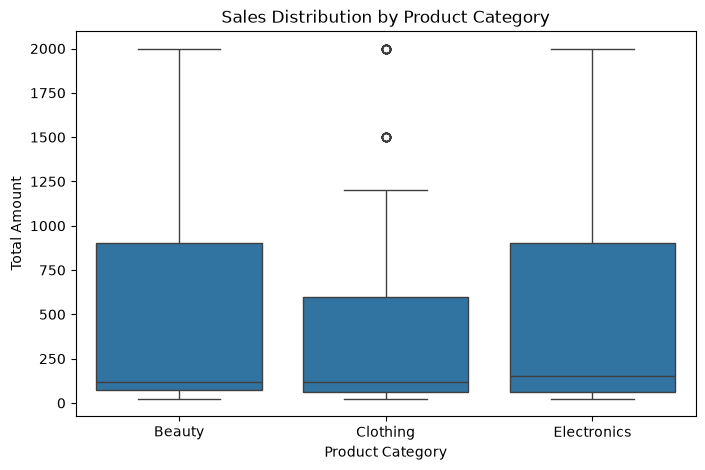

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Product Category',
    y='Total Amount'
)

plt.title("Sales Distribution by Product Category")
plt.savefig("images/sales_distribution.png")

plt.show()

## Observation

- The box plot compares transaction amounts across product categories.
- It highlights variations in spending and any unusually high-value purchases.

# Conclusion

Based on the Exploratory Data Analysis, the following business recommendations are suggested:

1. Focus marketing efforts on the highest-performing product categories to maximize revenue.

2. Monitor monthly and quarterly sales trends to prepare inventory and promotional campaigns during peak demand periods.

3. Design targeted marketing strategies for the dominant customer age group and gender to improve customer engagement.

4. Analyze high-value transactions to understand purchasing behavior and encourage similar sales through personalized offers.